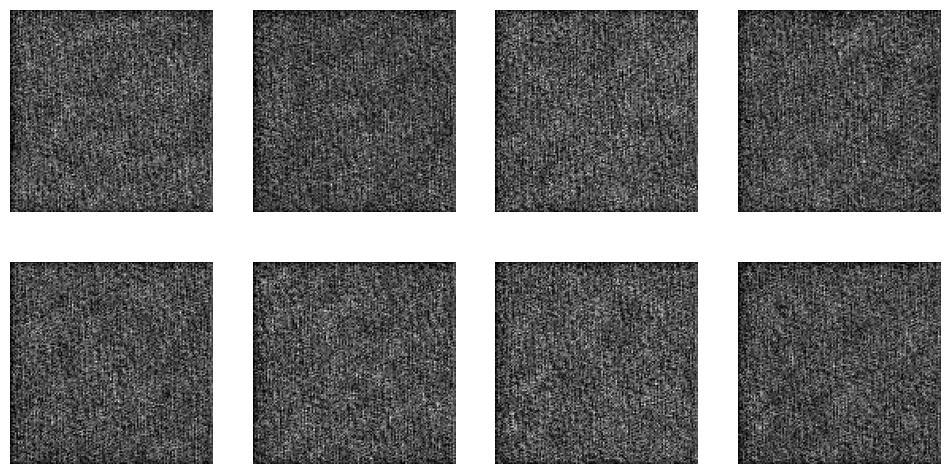

In [3]:
import torch
from matplotlib import pyplot as plt
from torch import nn



class BasicUNet(nn.Module):
    """A minimal UNet implementation."""

    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.down_layers = torch.nn.ModuleList(
            [
                nn.Conv2d(in_channels, 32, kernel_size=5, padding=2),
                nn.Conv2d(32, 64, kernel_size=5, padding=2),
                nn.Conv2d(64, 64, kernel_size=5, padding=2),
            ]
        )
        self.up_layers = torch.nn.ModuleList(
            [
                nn.Conv2d(64, 64, kernel_size=5, padding=2),
                nn.Conv2d(64, 32, kernel_size=5, padding=2),
                nn.Conv2d(32, out_channels, kernel_size=5, padding=2),
            ]
        )
        self.act = nn.ReLU()  # The activation function
        self.downscale = nn.MaxPool2d(2)
        self.upscale = nn.Upsample(scale_factor=2)

    def forward(self, x):
        h = []
        for i, l in enumerate(self.down_layers):
            x = self.act(l(x))  # Through the layer and the activation function
            if i < 2:  # For all but the third (final) down layer:
                h.append(x)  # Storing output for skip connection
                x = self.downscale(x)  # Downscale ready for the next layer

        for i, l in enumerate(self.up_layers):
            if i > 0:  # For all except the first up layer
                x = self.upscale(x)  # Upscale
                x += h.pop()  # Fetching stored output (skip connection)
            x = self.act(l(x))  # Through the layer and the activation function

        return x
# Generate a sample
model = BasicUNet()
device = torch.device("cuda:1")
state_dict = torch.load("/mnt/raid/home/ajarry/data/outputs_monai/output_20250114_101849/model.pth")
model.load_state_dict(state_dict, strict=False)
model = model.to(device)
shape = (1, 1, 128, 128)  # Adjust based on model's requirements
# List to store generated samples
samples = []

# Generate 8 samples
model.eval()
with torch.no_grad():
    for _ in range(8):
        # Generate a random sample
        noise = torch.randn(shape).to(device)  # Noise input
        sample = model(noise).cpu().squeeze()  # Generate image and move to CPU
        samples.append(sample)

# Plot the 8 samples in a 2x4 grid
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    # Transpose the sample to (H, W, C) and convert to numpy for plotting
    img = samples[i]
    ax.imshow(img,cmap="gray")
    ax.axis('off')

